# Exercise 6
**Cristina Correa - 1819211867**


Increase or decrease the output units in the hidden layers. How
sensitive is the model to changes in the number of neurons?

Using 242 samples for training and 61 for validation

Training model with 8 neurons in the hidden layer...
Train Accuracy: 0.8802, Validation Accuracy: 0.8033

Training model with 16 neurons in the hidden layer...
Train Accuracy: 0.9091, Validation Accuracy: 0.8197

Training model with 32 neurons in the hidden layer...
Train Accuracy: 0.9174, Validation Accuracy: 0.8033

Training model with 64 neurons in the hidden layer...
Train Accuracy: 0.9132, Validation Accuracy: 0.7869

Training model with 128 neurons in the hidden layer...
Train Accuracy: 0.9256, Validation Accuracy: 0.7869


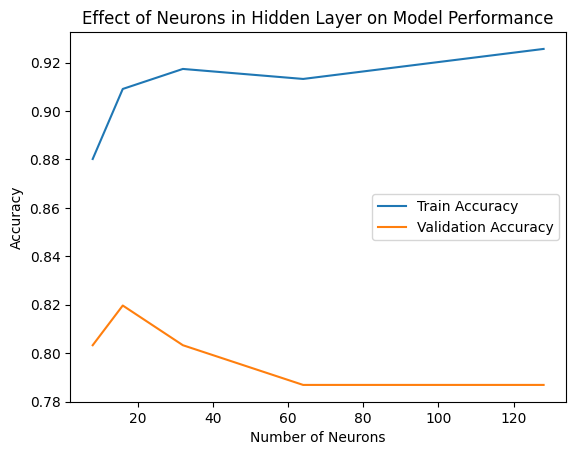

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model

os.environ["KERAS_BACKEND"] = "tensorflow"

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)


def dataframe_to_dataset(dataframe, target="target"):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
    return ds


train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)


def encode_feature(feature, name, dataset, is_string=False):
    lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
    lookup = lookup_class(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


def normalize_feature(feature, name, dataset):
    normalizer = layers.Normalization()
    feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)


inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]


def build_model(neurons):
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(neurons, activation="relu")(all_features)
    output = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


neuron_configs = [8, 16, 32, 64, 128]
results = {}

for neurons in neuron_configs:
    print(f"\nTraining model with {neurons} neurons in the hidden layer...")
    model = build_model(neurons)

    history = model.fit(train_ds, epochs=50, validation_data=val_ds, verbose=0)

    train_accuracy = history.history["accuracy"][-1]
    val_accuracy = history.history["val_accuracy"][-1]
    results[neurons] = {"train_accuracy": train_accuracy, "val_accuracy": val_accuracy}
    print(
        f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}"
    )

neuron_counts = list(results.keys())
train_accuracies = [results[n]["train_accuracy"] for n in neuron_counts]
val_accuracies = [results[n]["val_accuracy"] for n in neuron_counts]

plt.plot(neuron_counts, train_accuracies, label="Train Accuracy")
plt.plot(neuron_counts, val_accuracies, label="Validation Accuracy")
plt.xlabel("Number of Neurons")
plt.ylabel("Accuracy")
plt.title("Effect of Neurons in Hidden Layer on Model Performance")
plt.legend()
plt.show()

The observed trend, where increasing the number of neurons leads to better training accuracy but worse validation accuracy, is a classic case of overfitting. Overfitting occurs because a model with too many neurons can memorize the training data instead of learning generalizable patterns